,left,right,gender
1,24,27,male
2,22,22,female
3,37,39,male
4,20,20,male
5,1,16,male
6,8,20,female
7,14,14,male
8,21,21,male
9,18,18,male
10,1,13,female


<Axes: >

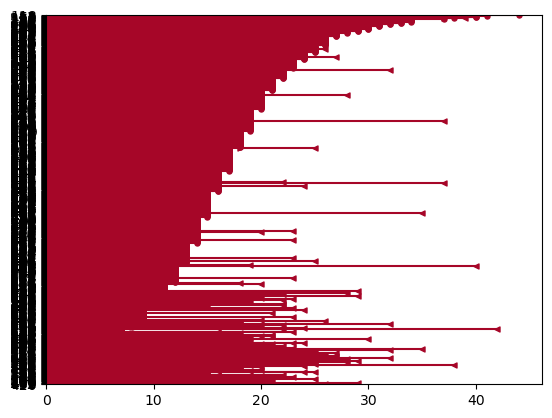

In [19]:
from lifelines.datasets import load_diabetes
from lifelines.plotting import plot_interval_censored_lifetimes

df = load_diabetes()
display(df.head(25))
plot_interval_censored_lifetimes(df['left'], df['right'])

<Axes: >

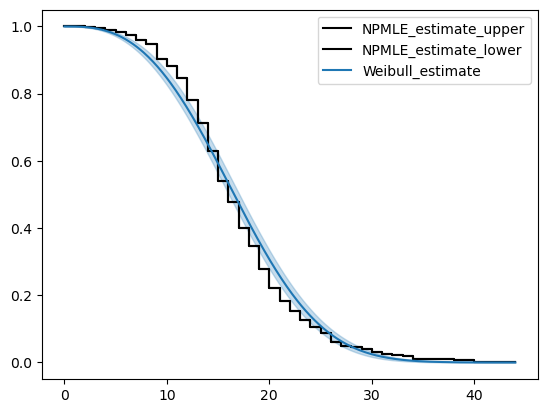

In [29]:
from lifelines import WeibullFitter, KaplanMeierFitter

df = load_diabetes()

wf = WeibullFitter()
wf.fit_interval_censoring(lower_bound=df['left'], upper_bound=df['right'])

# or, a non-parametric estimator:
# for now, this assumes closed observation intervals, ex: [4,5], not (4, 5) or (4, 5]
kmf = KaplanMeierFitter()
kmf.fit_interval_censoring(df['left'], df['right'])

ax = kmf.plot_survival_function()
wf.plot_survival_function(ax=ax)

Text(0.5, 0, 'Years from AIDS diagnosis')

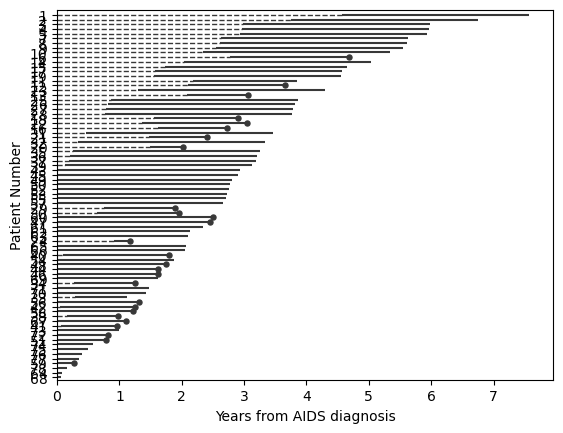

In [21]:
from matplotlib import pyplot as plt
from lifelines.datasets import load_multicenter_aids_cohort_study
from lifelines.plotting import plot_lifetimes

df = load_multicenter_aids_cohort_study()

plot_lifetimes(
    df["T"],
    event_observed=df["D"],
    entry=df["W"],
    event_observed_color="#383838",
    event_censored_color="#383838",
    left_truncated=True,
)
plt.ylabel("Patient Number")
plt.xlabel("Years from AIDS diagnosis")

In [30]:
import pandas as pd
from lifelines.utils import to_long_format

base_df = pd.DataFrame([
  {'id': 1, 'duration': 10, 'event': True, 'var1': 0.1},
  {'id': 2, 'duration': 12, 'event': True, 'var1': 0.5}
])

display(base_df)

base_df = to_long_format(base_df, duration_col="duration")
display(base_df)

,id,duration,event,var1
0,1,10,True,0.1
1,2,12,True,0.5


,id,event,var1,start,stop
0,1,True,0.1,0,10
1,2,True,0.5,0,12


In [31]:
from lifelines.utils import add_covariate_to_timeline

cv = pd.DataFrame([
  {'id': 1, 'time': 0, 'var2': 1.4},
  {'id': 1, 'time': 4, 'var2': 1.2},
  {'id': 1, 'time': 8, 'var2': 1.5},
  {'id': 2, 'time': 0, 'var2': 1.6},

])

display(cv)
df = add_covariate_to_timeline(base_df, cv, duration_col="time", id_col="id", event_col="event")
df = df[['id', 'start','stop', 'var1', 'var2']]
df

,id,time,var2
0,1,0,1.4
1,1,4,1.2
2,1,8,1.5
3,2,0,1.6


,id,start,stop,var1,var2
0,1,0,4.0,0.1,1.4
1,1,4,8.0,0.1,1.2
2,1,8,10.0,0.1,1.5
3,2,0,12.0,0.5,1.6


In [32]:
event_df = pd.DataFrame([
    {'id': 1, 'E1': 1.0},
    {'id': 2, 'E1': None},
    {'id': 3, 'E1': 3.0},
])

print(event_df)

   id   E1
0   1  1.0
1   2  NaN
2   3  3.0


In [33]:
from lifelines.utils import covariates_from_event_matrix

cv = covariates_from_event_matrix(event_df, id_col="id")
print(cv)


   id  duration   E1
0   1       1.0  1.0
1   2       inf  1.0
2   3       3.0  1.0


In [34]:
base_df = pd.DataFrame([
    {'id': 1, 'duration': 10, 'event': True, 'var1': 0.1},
    {'id': 2, 'duration': 12, 'event': True, 'var1': 0.5}
])
display(base_df)
base_df = to_long_format(base_df, duration_col="duration")
display(base_df)

,id,duration,event,var1
0,1,10,True,0.1
1,2,12,True,0.5


,id,event,var1,start,stop
0,1,True,0.1,0,10
1,2,True,0.5,0,12


Iteration 1: norm_delta = 9.60e-01, step_size = 0.9500, log_lik = -0.69315, newton_decrement = 3.57e-01, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.76e-01, step_size = 0.9500, log_lik = -0.32113, newton_decrement = 9.06e-03, seconds_since_start = 0.0
Iteration 3: norm_delta = 1.80e-02, step_size = 0.9500, log_lik = -0.31185, newton_decrement = 8.61e-05, seconds_since_start = 0.0
Iteration 4: norm_delta = 1.05e-03, step_size = 1.0000, log_lik = -0.31177, newton_decrement = 2.60e-07, seconds_since_start = 0.0
Iteration 5: norm_delta = 3.02e-07, step_size = 1.0000, log_lik = -0.31177, newton_decrement = 2.16e-14, seconds_since_start = 0.0
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 2 periods, 2 subjects, 2 events>
         event col = 'event'
         penalizer = 0.1
number of subjects = 2
 number of periods = 2
  number of events = 2
partial log-likelihood = -0.31
  time fit was run = 2025-08-13 20:58:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
var1      -4.08      0.02      5.14          -14.16            5.99                0.00              398.74

           cmp to     z    p  -log2(p)
covariate                             
var1         0.00 -0.79 0.43      1.23
---
Partial AIC = 2.62
log-likelihood ratio test = 0.76 on 1 df
-log2(p) of ll-ratio test = 1.39

<Axes: xlabel='log(HR) (95% CI)'>

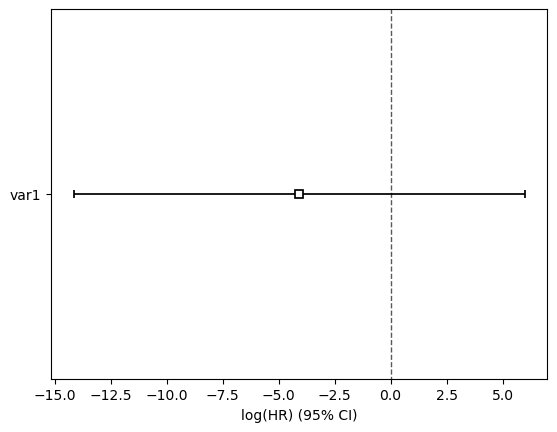

In [27]:
from lifelines import CoxTimeVaryingFitter

ctv = CoxTimeVaryingFitter(penalizer=0.1)
ctv.fit(base_df, id_col="id", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()

In [36]:

from lifelines.datasets import load_rossi
from lifelines.utils import to_episodic_format
long_rossi = load_rossi()
print(long_rossi.columns)
display(long_rossi.head(25))
long_rossi = to_episodic_format(rossi, 'week', 'arrest', time_gaps=2.)
print(long_rossi.columns)



from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()
# age variable violates proportional hazard
long_rossi['time * age'] = long_rossi['stop'] * long_rossi['age']
ctv.fit(long_rossi, id_col='id', event_col='arrest', show_progress=True)
ctv.print_summary()

Index(['week', 'arrest', 'fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio'], dtype='object')


,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3
5,52,0,0,24,1,1,0,0,2
6,23,1,0,25,1,1,1,1,0
7,52,0,1,21,1,1,0,1,4
8,52,0,0,22,1,0,0,0,6
9,52,0,0,20,1,1,0,0,0


Index(['stop', 'start', 'arrest', 'age', 'fin', 'id', 'mar', 'paro', 'prio',
       'race', 'wexp'],
      dtype='object')
Iteration 1: norm_delta = 1.42e+00, step_size = 0.9500, log_lik = -675.38063, newton_decrement = 2.16e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 9.29e-01, step_size = 0.9500, log_lik = -653.63874, newton_decrement = 3.08e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.16e-01, step_size = 0.9500, log_lik = -650.23417, newton_decrement = 2.22e-01, seconds_since_start = 0.0
Iteration 4: norm_delta = 4.03e-02, step_size = 1.0000, log_lik = -650.00428, newton_decrement = 2.96e-03, seconds_since_start = 0.0
Iteration 5: norm_delta = 3.15e-04, step_size = 1.0000, log_lik = -650.00131, newton_decrement = 1.89e-07, seconds_since_start = 0.1
Iteration 6: norm_delta = 2.01e-08, step_size = 1.0000, log_lik = -650.00131, newton_decrement = 7.81e-16, seconds_since_start = 0.1
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 9929 periods, 432 subjects, 114 events>
         event col = 'arrest'
number of subjects = 432
 number of periods = 9929
  number of events = 114
partial log-likelihood = -650.00
  time fit was run = 2025-08-13 21:00:01 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
age         0.09      1.09      0.04            0.02            0.16                1.02                1.18
fin        -0.38      0.69      0.19           -0.75           -0.00                0.47                1.00
mar        -0.38      0.68      0.38           -1.13            0.37                0.32                1.45
paro       -0.10      0.90      0.20           -0.49            0.28                0.61                1.33
prio        0.10      1.10      0.03            0.04            0.15                1.04                1.16
race        0.34      1.40      0.31           -0.26            0.94                0.77                2.57
wexp       -0.09      0.92      0.21           -0.51            0.33                0.60                1.39
time * age -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00

            cmp to     z      p  -log2(p)
covariate                                
age           0.00  2.44   0.01      6.10
fin           0.00 -1.97   0.05      4.36
mar           0.00 -0.99   0.32      1.64
paro          0.00 -0.52   0.60      0.73
prio          0.00  3.32 <0.005     10.12
race          0.00  1.10   0.27      1.89
wexp          0.00 -0.42   0.68      0.56
time * age    0.00 -4.00 <0.005     13.97
---
Partial AIC = 1316.00
log-likelihood ratio test = 50.76 on 8 df
-log2(p) of ll-ratio test = 25.03

In [37]:
from functions_cox import *

In [38]:
from functions_cox import *
df = load_and_prepare_data()
df.head(30)

Loading and preparing data...


KeyError: ['pid_pde']

In [ ]:
df2 = create_survival_data(df)
df2.sort_values(by='pid_pde', inplace=True)
df2

Creating survival analysis dataset...


,pid_pde,time,event,sex,age_start,job_code_start,married_start
0,PDE1,4.501027,True,1.0,27.0,11A,0.0
1,PDE10,3.753593,False,1.0,26.0,11A,0.0
2,PDE11,3.000684,False,0.0,24.0,12A,0.0
3,PDE12,6.499658,False,1.0,27.0,11A,1.0
4,PDE13,3.249829,False,1.0,27.0,11A,0.0
5,PDE2,3.249829,True,1.0,27.0,11A,0.0
6,PDE3,5.998631,True,1.0,33.0,11A,1.0
7,PDE4,4.501027,True,0.0,27.0,12A,0.0
8,PDE5,3.249829,True,0.0,24.0,12A,0.0
9,PDE6,6.499658,True,1.0,27.0,11A,0.0
